# Master Ranking Table Generation Walkthrough

This notebook demonstrates the process of creating a "Silver Master Ranking" table by aggregating and normalizing player rankings from various sources found in the Bronze layer.

## Goal
- Load raw rankings from `bronze_ff_rankings`
- Normalize rankings from different sources (Best Ball, Redraft, IDP, etc.) to a common scale (0-100)
- Map players using `bronze_ff_playerids`
- Aggregate scores to create a final Master Ranking
- Visualize the results

In [1]:
import polars as pl
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data from Bronze Layer

We connect to the `nfl.db` SQLite database and load the raw rankings and player IDs.

In [2]:
db_path = "../data/nfl.db"
conn = sqlite3.connect(db_path)

# Load rankings (inference schema length increased for safety)
df_rankings = pl.read_database("SELECT * FROM bronze_ff_rankings", conn, infer_schema_length=10000)

# Load player IDs
df_ids = pl.read_database("SELECT * FROM bronze_ff_playerids", conn, infer_schema_length=10000)

conn.close()

print(f"Loaded {len(df_rankings)} ranking entries and {len(df_ids)} player IDs.")

Loaded 4962 ranking entries and 12186 player IDs.


## 2. Explore Ranking Sources

Let's look at the different types of rankings available (e.g., Redraft vs Best Ball, different positions).

In [3]:
df_rankings = df_rankings.filter(pl.col("id").is_not_null())

# Create a combined source key
df_rankings = df_rankings.with_columns([
    (pl.col("page_type") + "_" + pl.col("ecr_type")).alias("source_key")
])

# Count entries per source
source_counts = df_rankings.group_by("source_key").len().sort("len", descending=True)
print(source_counts.head(10))

shape: (10, 2)
┌────────────────────┬─────┐
│ source_key         ┆ len │
│ ---                ┆ --- │
│ str                ┆ u32 │
╞════════════════════╪═════╡
│ dynasty-idp_do     ┆ 517 │
│ dynasty-op_dsf     ┆ 453 │
│ dynasty-overall_do ┆ 448 │
│ best-overall_bo    ┆ 447 │
│ redraft-overall_ro ┆ 326 │
│ redraft-op_rsf     ┆ 300 │
│ dynasty-db_dp      ┆ 274 │
│ dynasty-dl_dp      ┆ 262 │
│ dynasty-lb_dp      ┆ 254 │
│ dynasty-wr_dp      ┆ 212 │
└────────────────────┴─────┘


## 3. Normalize Rankings

Different ranking lists have different lengths (depths). A rank of #10 in a list of 50 is different from #10 in a list of 300.

We normalize ranks to a **Percentile Score (0-100)**:
$$ Score = 100 \times (1 - \frac{Rank - 1}{MaxRank - 1}) $$

In [4]:
# Normalize Scores
df_rankings = df_rankings.with_columns(
    pl.col("ecr").max().over("source_key").alias("max_rank_in_source")
).with_columns(
    pl.when(pl.col("max_rank_in_source") > 1)
    .then(100.0 * (1.0 - (pl.col("ecr") - 1.0) / (pl.col("max_rank_in_source") - 1.0)))
    .otherwise(100.0)
    .alias("normalized_score")
)

# Show sample of normalized scores
print(df_rankings.select(["player", "source_key", "ecr", "max_rank_in_source", "normalized_score"]).head())

shape: (5, 5)
┌─────────────────────┬─────────────┬─────┬────────────────────┬──────────────────┐
│ player              ┆ source_key  ┆ ecr ┆ max_rank_in_source ┆ normalized_score │
│ ---                 ┆ ---         ┆ --- ┆ ---                ┆ ---              │
│ str                 ┆ str         ┆ f64 ┆ f64                ┆ f64              │
╞═════════════════════╪═════════════╪═════╪════════════════════╪══════════════════╡
│ Denver Broncos      ┆ best-dst_bp ┆ 1.0 ┆ 31.0               ┆ 100.0            │
│ Philadelphia Eagles ┆ best-dst_bp ┆ 2.4 ┆ 31.0               ┆ 95.333333        │
│ Pittsburgh Steelers ┆ best-dst_bp ┆ 2.8 ┆ 31.0               ┆ 94.0             │
│ Baltimore Ravens    ┆ best-dst_bp ┆ 4.6 ┆ 31.0               ┆ 88.0             │
│ Minnesota Vikings   ┆ best-dst_bp ┆ 5.4 ┆ 31.0               ┆ 85.333333        │
└─────────────────────┴─────────────┴─────┴────────────────────┴──────────────────┘


## 4. Map IDs and Aggregate Master Score

We join with the ID table to ensure we have consistent player metadata, then calculate the average `normalized_score` for each player across all sources they appear in.

In [5]:
# Prepare IDs for join
df_ids = df_ids.rename({"fantasypros_id": "id"})
df_rankings = df_rankings.with_columns(pl.col("id").cast(pl.Int64))
df_ids = df_ids.with_columns(pl.col("id").cast(pl.Int64))

# Join
df_merged = df_rankings.join(df_ids, on="id", how="left", suffix="_mapped")

# Coalesce Metadata
df_merged = df_merged.with_columns([
    pl.coalesce(pl.col("name"), pl.col("player")).alias("final_name"),
    pl.coalesce(pl.col("position"), pl.col("pos")).alias("final_pos"),
    pl.coalesce(pl.col("team"), pl.col("tm")).alias("final_team")
])

# Aggregate
df_master = df_merged.group_by("id").agg([
    pl.col("final_name").first().alias("player_name"),
    pl.col("final_pos").first().alias("position"),
    pl.col("final_team").first().alias("team"),
    pl.col("normalized_score").mean().alias("master_score"),
    pl.col("ecr").mean().alias("avg_raw_rank"),
    pl.col("source_key").count().alias("rank_count")
])

# Calculate Final Rank
df_master = df_master.sort("master_score", descending=True).with_columns(
    pl.arange(1, pl.len() + 1).alias("master_rank")
)

print(df_master.head(10))

shape: (10, 8)
┌───────┬───────────────┬──────────┬──────┬──────────────┬──────────────┬────────────┬─────────────┐
│ id    ┆ player_name   ┆ position ┆ team ┆ master_score ┆ avg_raw_rank ┆ rank_count ┆ master_rank │
│ ---   ┆ ---           ┆ ---      ┆ ---  ┆ ---          ┆ ---          ┆ ---        ┆ ---         │
│ i64   ┆ str           ┆ str      ┆ str  ┆ f64          ┆ f64          ┆ u32        ┆ i64         │
╞═══════╪═══════════════╪══════════╪══════╪══════════════╪══════════════╪════════════╪═════════════╡
│ 19788 ┆ Ja'Marr Chase ┆ WR       ┆ CIN  ┆ 99.431325    ┆ 2.835        ┆ 8          ┆ 1           │
│ 18702 ┆ Maxx Crosby   ┆ DE       ┆ LV   ┆ 99.359951    ┆ 3.585        ┆ 2          ┆ 2           │
│ 17311 ┆ Roquan Smith  ┆ LB       ┆ BAL  ┆ 99.322449    ┆ 3.415        ┆ 2          ┆ 3           │
│ 23133 ┆ Bijan         ┆ RB       ┆ ATL  ┆ 99.106407    ┆ 4.165        ┆ 8          ┆ 4           │
│       ┆ Robinson      ┆          ┆      ┆              ┆              ┆   

## 5. Visualizations

### Master Score Distribution
How are the scores distributed? Do we have a smooth curve or clusters of elite players?

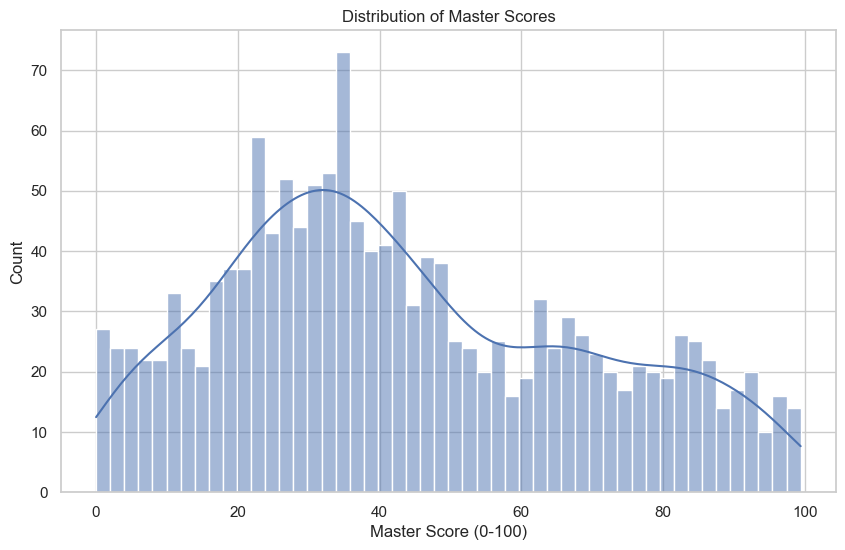

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_master, x="master_score", bins=50, kde=True)
plt.title("Distribution of Master Scores")
plt.xlabel("Master Score (0-100)")
plt.show()

### Top 15 Players
Who are the top players according to our aggregated rankings?

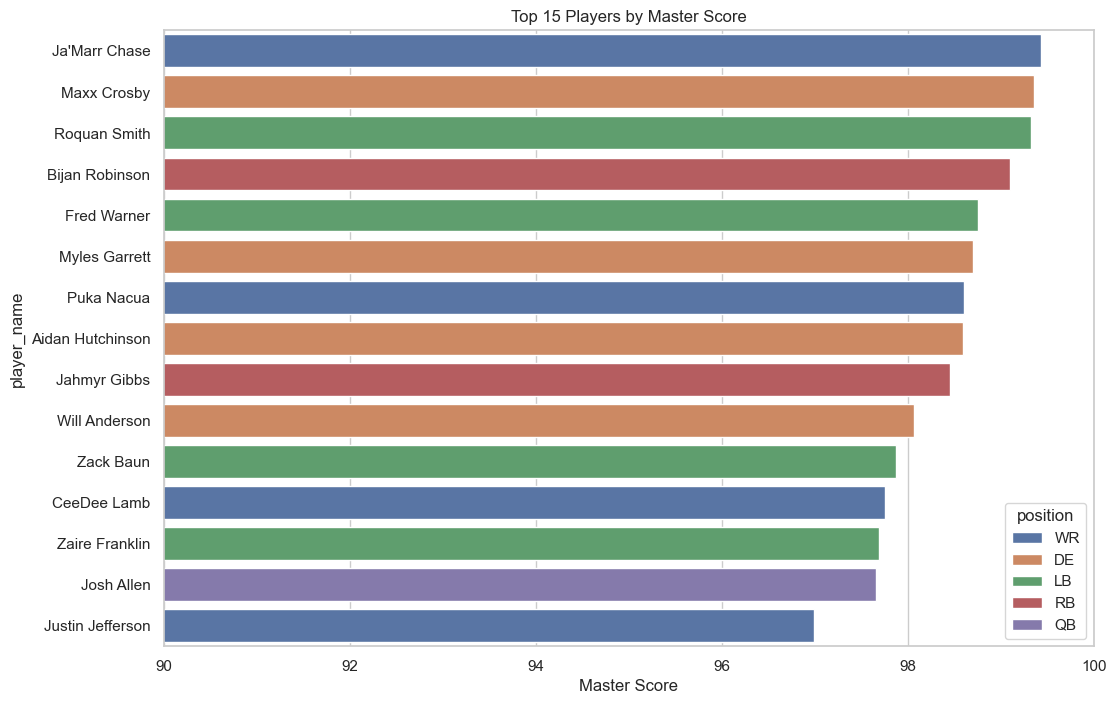

In [7]:
top_15 = df_master.head(15)

plt.figure(figsize=(12, 8))
sns.barplot(data=top_15, x="master_score", y="player_name", hue="position", dodge=False)
plt.title("Top 15 Players by Master Score")
plt.xlabel("Master Score")
plt.xlim(90, 100) # Zoom in on the top scores
plt.show()

### Consensus Strength
How many ranking sources contributed to each player's score? Players with more sources (higher count) have a more reliable consensus.

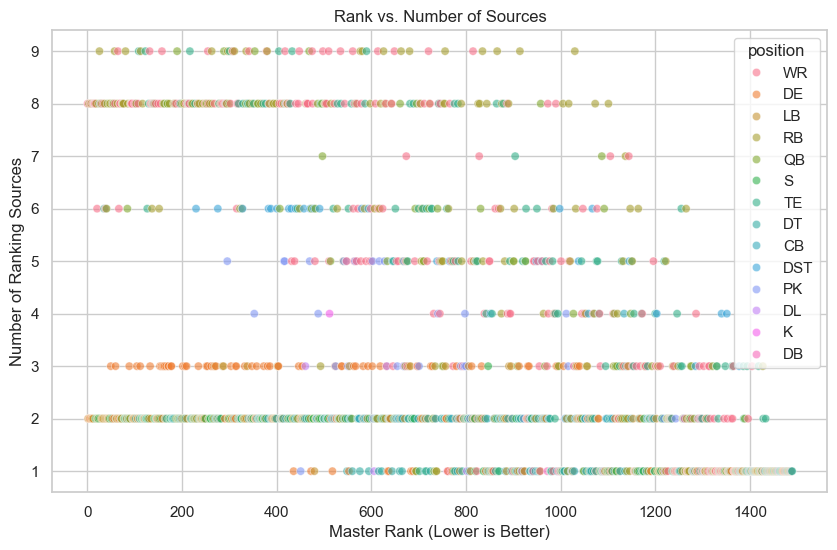

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_master, x="master_rank", y="rank_count", hue="position", alpha=0.6)
plt.title("Rank vs. Number of Sources")
plt.xlabel("Master Rank (Lower is Better)")
plt.ylabel("Number of Ranking Sources")
plt.show()

In [9]:
df_master.head(50)

id,player_name,position,team,master_score,avg_raw_rank,rank_count,master_rank
i64,str,str,str,f64,f64,u32,i64
19788,"""Ja'Marr Chase""","""WR""","""CIN""",99.431325,2.835,8,1
18702,"""Maxx Crosby""","""DE""","""LV""",99.359951,3.585,2,2
17311,"""Roquan Smith""","""LB""","""BAL""",99.322449,3.415,2,3
23133,"""Bijan Robinson""","""RB""","""ATL""",99.106407,4.165,8,4
17526,"""Fred Warner""","""LB""","""SF""",98.761692,5.25,2,5
…,…,…,…,…,…,…,…
18716,"""Kaden Elliss""","""LB""","""ATL""",93.062812,24.335,2,46
22958,"""James Cook""","""RB""","""BUF""",92.964501,21.985,8,47
19216,"""Xavier McKinney""","""S""","""GB""",92.732108,30.5,2,48


In [10]:
df_rankings.head()

fp_page,page_type,ecr_type,player,id,pos,team,ecr,sd,best,worst,sportsdata_id,player_filename,yahoo_id,cbs_id,player_owned_avg,player_owned_espn,player_owned_yahoo,player_image_url,player_square_image_url,rank_delta,bye,mergename,scrape_date,tm,source_key,max_rank_in_source,normalized_score
str,str,str,str,i64,str,str,f64,f64,i64,i64,null,str,null,null,f64,null,null,null,null,str,i64,str,str,str,str,f64,f64
"""/nfl/rankings/best-ball-dst.ph…","""best-dst""","""bp""","""Denver Broncos""",8090,"""DST""","""DEN""",1.0,0.0,1,1,null,"""denver-defense.php""",null,null,96.3,null,null,null,null,null,12,"""Denver Broncos""","""2026-01-16""","""DEN""","""best-dst_bp""",31.0,100.0
"""/nfl/rankings/best-ball-dst.ph…","""best-dst""","""bp""","""Philadelphia Eagles""",8230,"""DST""","""PHI""",2.4,0.49,2,3,null,"""philadelphia-defense.php""",null,null,82.3,null,null,null,null,null,9,"""Philadelphia Eagles""","""2026-01-16""","""PHI""","""best-dst_bp""",31.0,95.333333
"""/nfl/rankings/best-ball-dst.ph…","""best-dst""","""bp""","""Pittsburgh Steelers""",8240,"""DST""","""PIT""",2.8,0.4,2,3,null,"""pittsburgh-defense.php""",null,null,85.2,null,null,null,null,null,5,"""Pittsburgh Steelers""","""2026-01-16""","""PIT""","""best-dst_bp""",31.0,94.0
"""/nfl/rankings/best-ball-dst.ph…","""best-dst""","""bp""","""Baltimore Ravens""",8020,"""DST""","""BAL""",4.6,0.49,4,5,null,"""baltimore-defense.php""",null,null,60.9,null,null,null,null,null,7,"""Baltimore Ravens""","""2026-01-16""","""BAL""","""best-dst_bp""",31.0,88.0
"""/nfl/rankings/best-ball-dst.ph…","""best-dst""","""bp""","""Minnesota Vikings""",8170,"""DST""","""MIN""",5.4,1.2,4,7,null,"""minnesota-defense.php""",null,null,57.4,null,null,null,null,null,6,"""Minnesota Vikings""","""2026-01-16""","""MIN""","""best-dst_bp""",31.0,85.333333


<Axes: xlabel='player_owned_avg', ylabel='Count'>

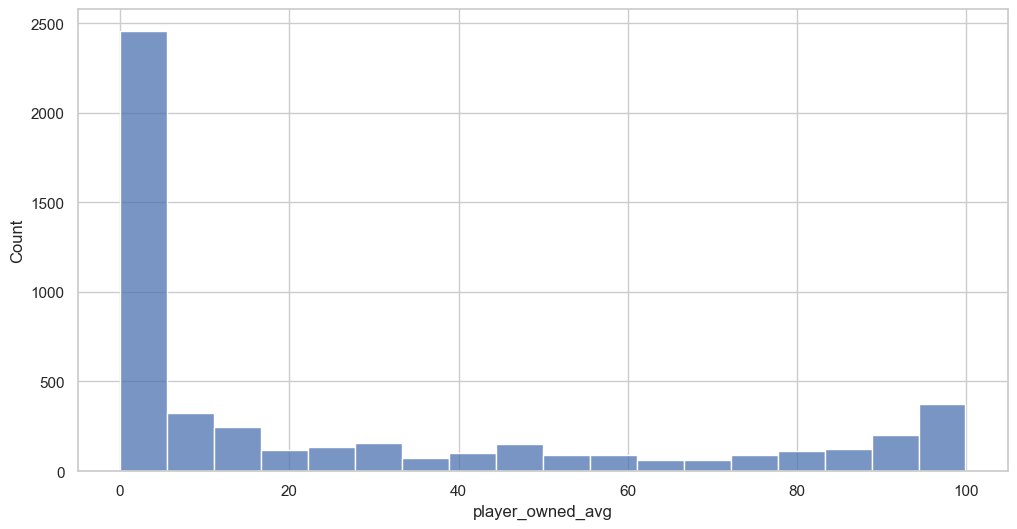

In [11]:
import seaborn as sns

sns.histplot(
    data=df_rankings,
    x="player_owned_avg"
)